This notebook is made for analyzing the results of a logistic classifier on the epigenome --> Age DEG model. 

author: Amit Klein
date: 1/9/2025

# Imports

In [1]:
import os, sys, time

from pathlib import Path
import pickle 
import json 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

import PyComplexHeatmap as pch
from PyComplexHeatmap import *

In [2]:
from sklearn.metrics import mutual_info_score, confusion_matrix

In [3]:
# My ordering
cell_types = ['L23_IT_CTX_Glut','L5_ET_CTX_Glut','L6_IT_CTX_Glut','L6_CT_CTX_Glut','CA3_Glut','CA1-ProS_Glut','DG_Glut','Astro-TE_NN','Oligo_NN','OPC_NN',]
# To match RZ's ordering in her plots
cell_types = ['Oligo_NN', 'OPC_NN', 'Astro-TE_NN', 'L23_IT_CTX_Glut', 'L6_IT_CTX_Glut', 'L6_CT_CTX_Glut', 'L5_ET_CTX_Glut', 'CA1-ProS_Glut', 'CA3_Glut', 'DG_Glut']

## Colormap Setup
This segment I will probably need to reproduce in all of my analysis notebooks (can I just save the colormap in my own version of matplotlib?)

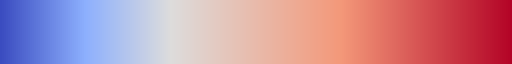

In [4]:
from matplotlib.colors import LinearSegmentedColormap

# cmap = plt.get_cmap("coolwarm")
# cmap(np.linspace(0, 1, 5))

adj_coolwarm = LinearSegmentedColormap.from_list("adjusted_coolwarm", (
    (0.000, (0.2298057 , 0.29871797, 0.75368315)),
    (0.166, (0.55431187, 0.69009701, 0.99551555)),
    (0.333, (0.86742764, 0.8643766 , 0.86260246)),
    (0.666, (0.95665321, 0.59803382, 0.47730229)),
    (1.000, (0.70567316, 0.01555616, 0.15023281))))

adj_coolwarm

# CV Model Training Results

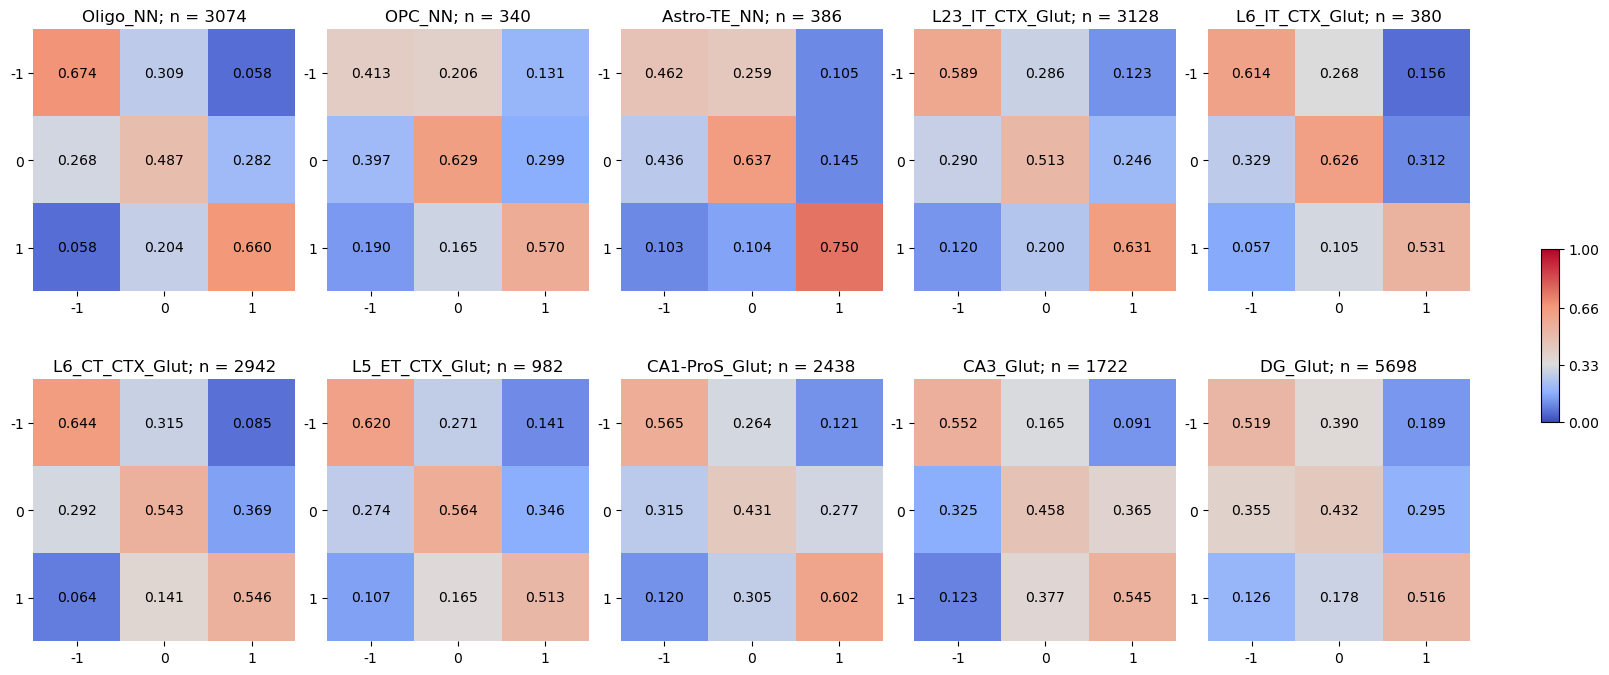

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7), constrained_layout=True)

for i, _ct in enumerate(cell_types): 
    ax = axes.flatten()[i]
    
    Y_output = pd.read_csv(f"../result_data/linear_baseline/model_metrics/{_ct}.preds.csv", index_col=0)
    n_sample = Y_output.shape[0]
    
    ccf = confusion_matrix(Y_output['label'], Y_output['pred'], normalize='true')
    g = ax.imshow(ccf, cmap=adj_coolwarm, vmin=0, vmax=1)
    ax.set(xticks=range(ccf.shape[1]), yticks=range(ccf.shape[0]), 
           xticklabels = ['-1', '0', '1'], yticklabels = ['-1', '0', '1'], 
           )
    sns.despine(left=True, bottom=True)

    for a in range(3):
        for b in range(3):
            ax.text(a, b, "%.3f"%(ccf[a, b]), size=10, va='center', ha='center')
            
    ax.set_title(f"{_ct}; n = {n_sample}")

for i in range(len(cell_types), 10): 
    axes.flatten()[i].remove()

fig.colorbar(g, ax=axes, ticks=[0, 0.33, 0.66, 1], label="", location='right', aspect=10, shrink=0.25, fraction=1)
plt.show()    

In [6]:
diag_acc = {}
n_samps = {}
for i, _ct in enumerate(cell_types): 

    Y_output = pd.read_csv(f"../result_data/linear_baseline/model_metrics/{_ct}.preds.csv", index_col=0)
    n_sample = Y_output.shape[0]
    
    ccf_test = confusion_matrix(Y_output['label'], Y_output['pred'], normalize='true')
    diag_acc[_ct] = [ccf_test[0, 0], ccf_test[1, 1], ccf_test[2, 2]]
    n_samps[_ct] = [(Y_output['label'] == 0).sum(), (Y_output['label'] == 1).sum(), (Y_output['label'] == 2).sum()]
    # break
df_diag_acc = pd.DataFrame.from_dict(diag_acc)
df_N = pd.DataFrame.from_dict(n_samps)

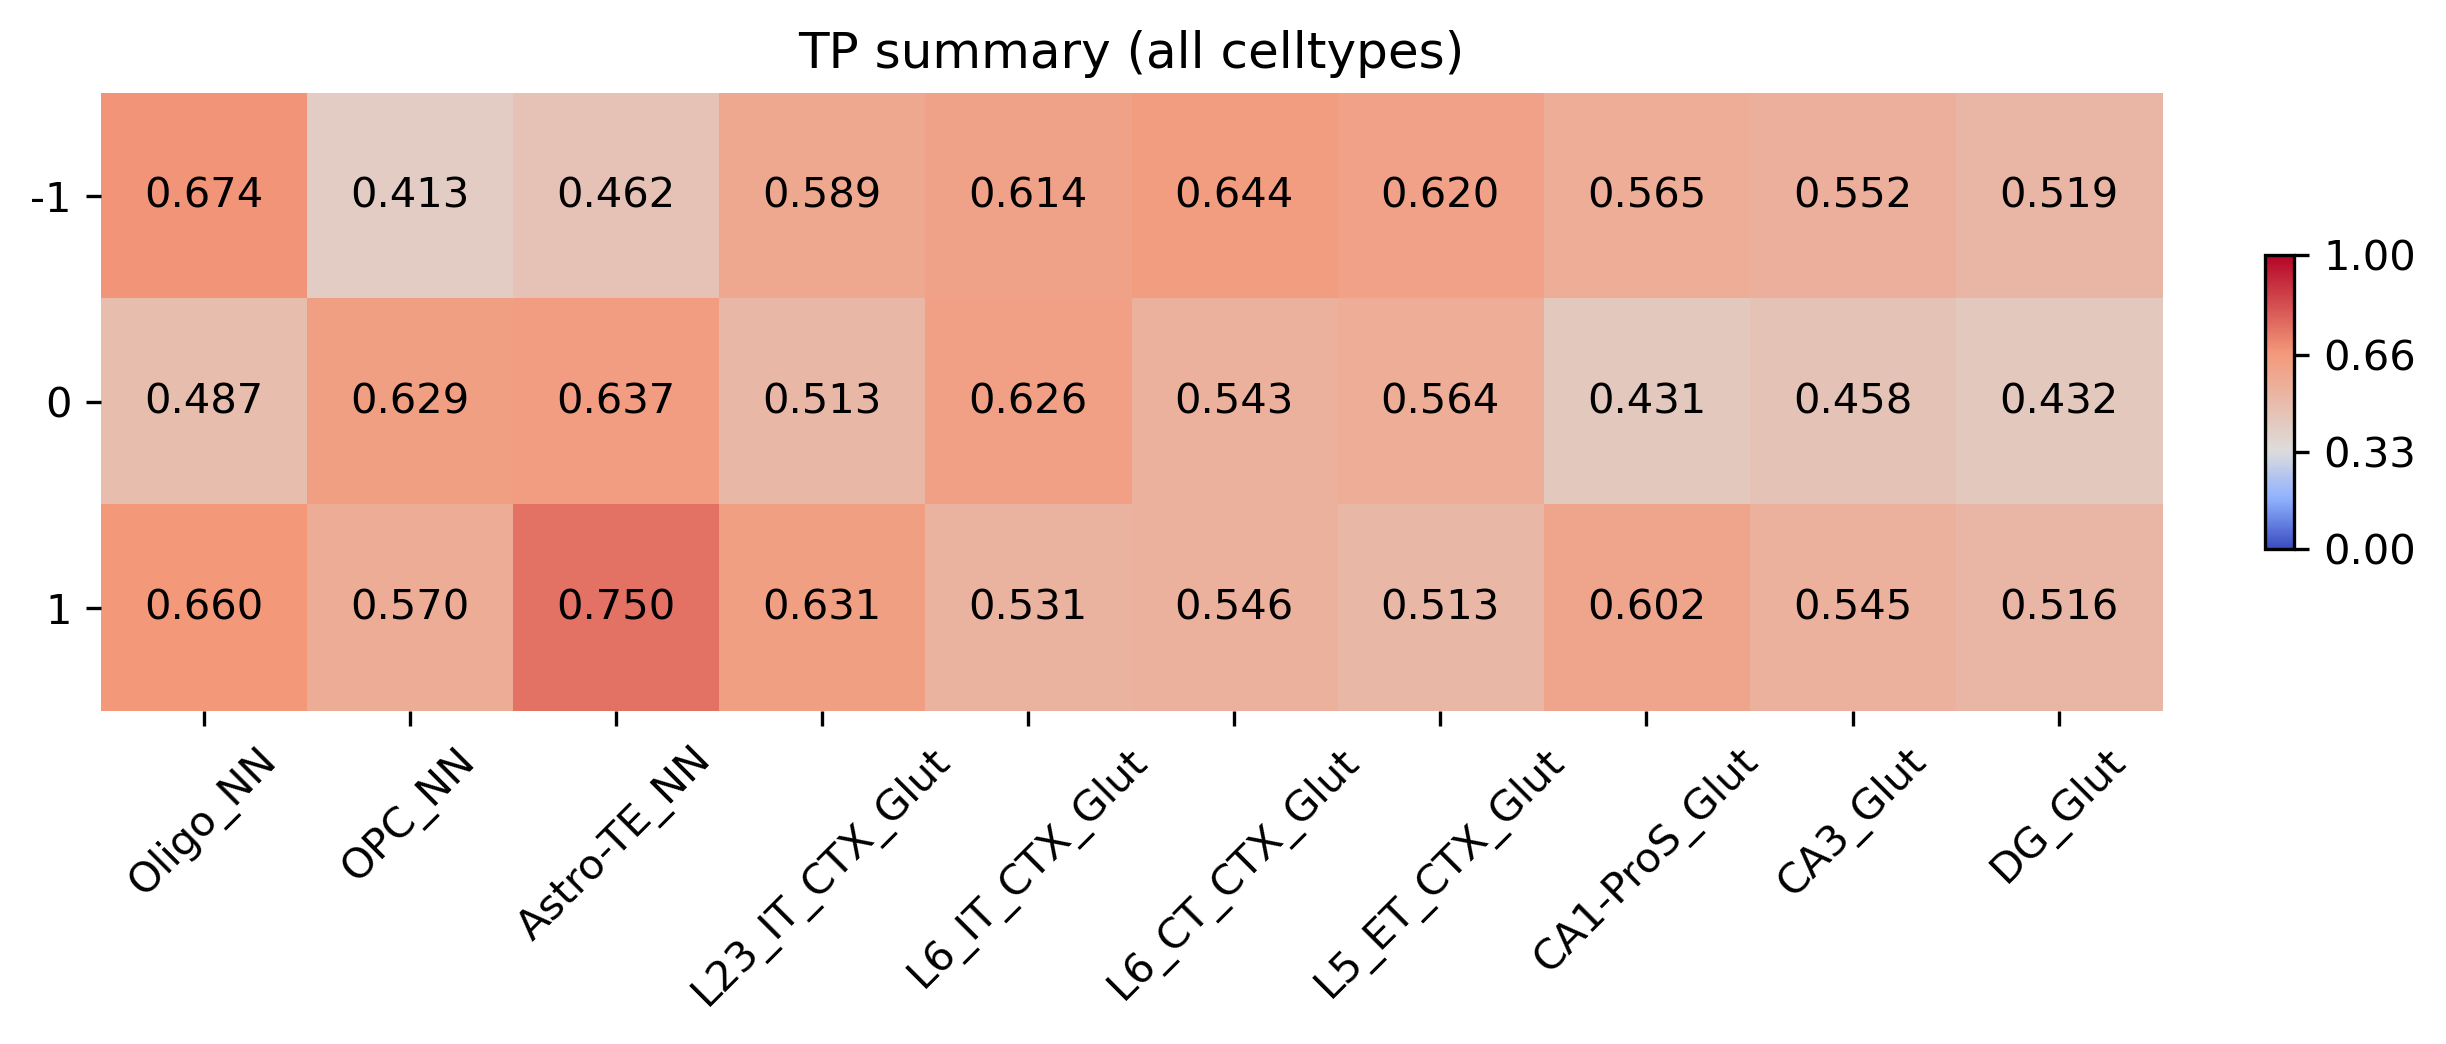

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300, constrained_layout=True)

g = ax.imshow(df_diag_acc, cmap=adj_coolwarm, vmin=0, vmax=1)
ax.set(xticks=range(df_diag_acc.shape[1]), yticks=range(df_diag_acc.shape[0]), 
       xticklabels=df_diag_acc.columns, yticklabels = ['-1', '0', '1'], )
ax.tick_params(axis='x', rotation=45)
sns.despine(left=True, bottom=True)

for a in range(df_diag_acc.shape[0]):
    for b in range(df_diag_acc.shape[1]):
        ax.text(b, a, "%.3f"%(df_diag_acc.iloc[a, b]), size=10, va='center', ha='center')
        
ax.set_title(f"TP summary (all celltypes)")

# sns.heatmap(df_diag_acc, square=True, cmap=adj_coolwarm, annot=True, vmin=0, vmax=1, center=0.33,
#             yticklabels=['-1', '0', '1'], ax=ax)

fig.colorbar(g, ax=ax, ticks=[0, 0.33, 0.66, 1], label="", location='right', aspect=10, shrink=0.25, fraction=1)

plt.show()
plt.close()

## CV Weight Analysis

### Weight Dist

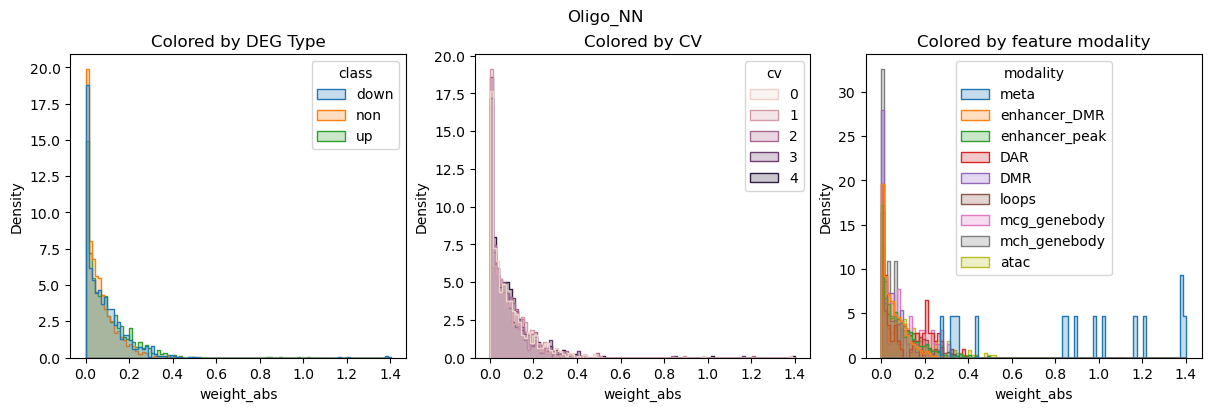

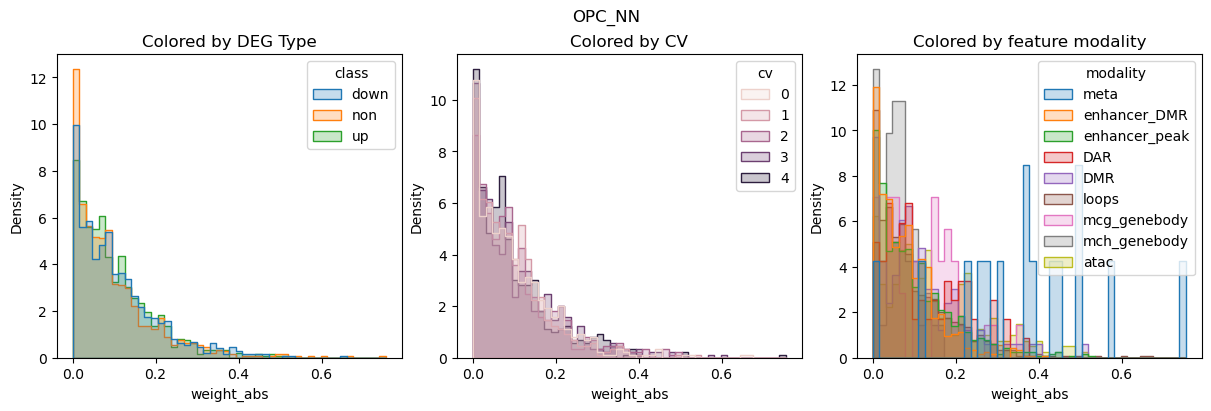

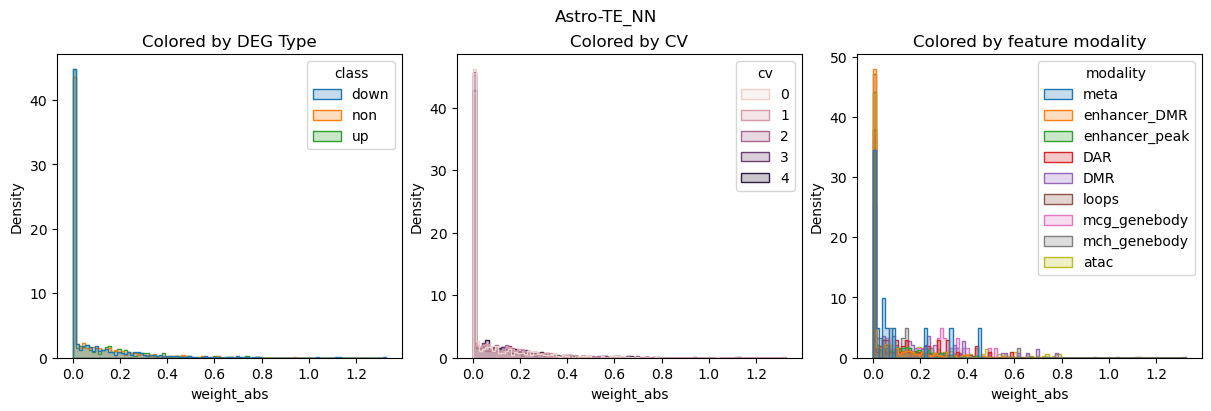

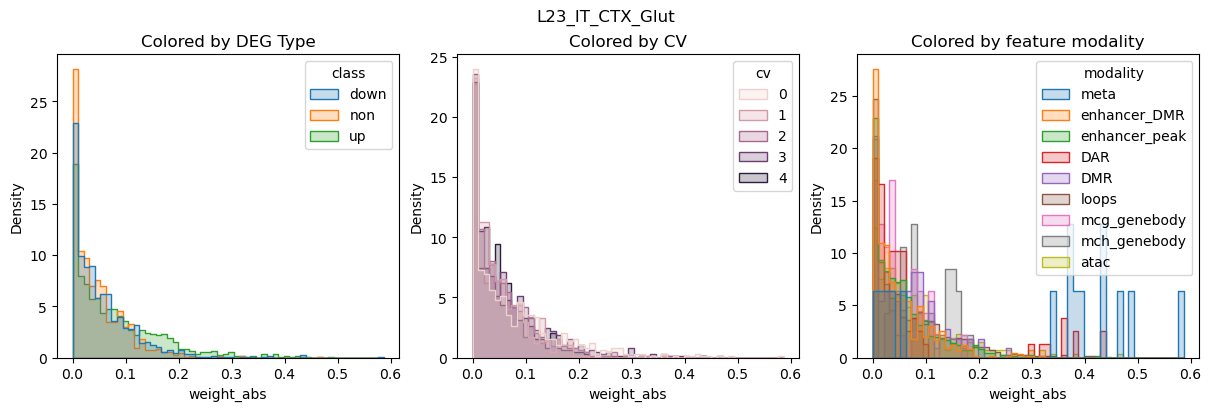

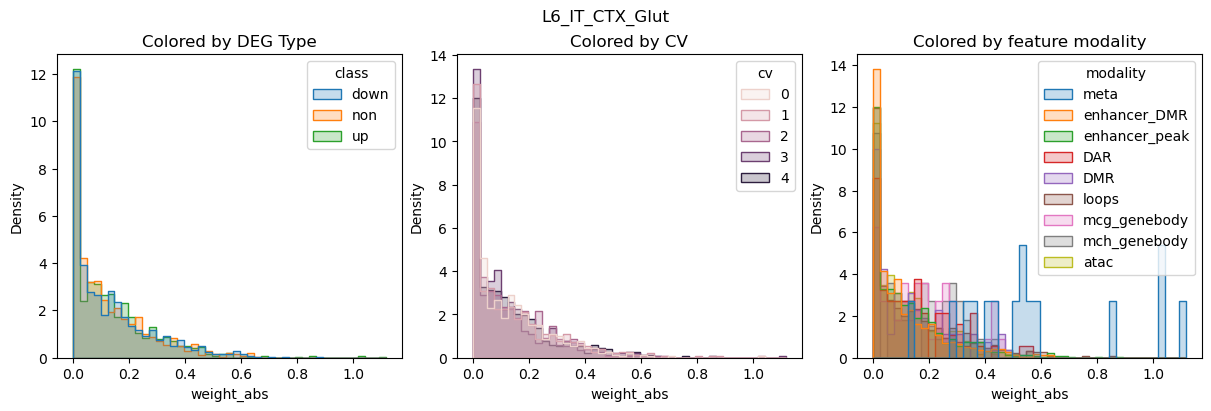

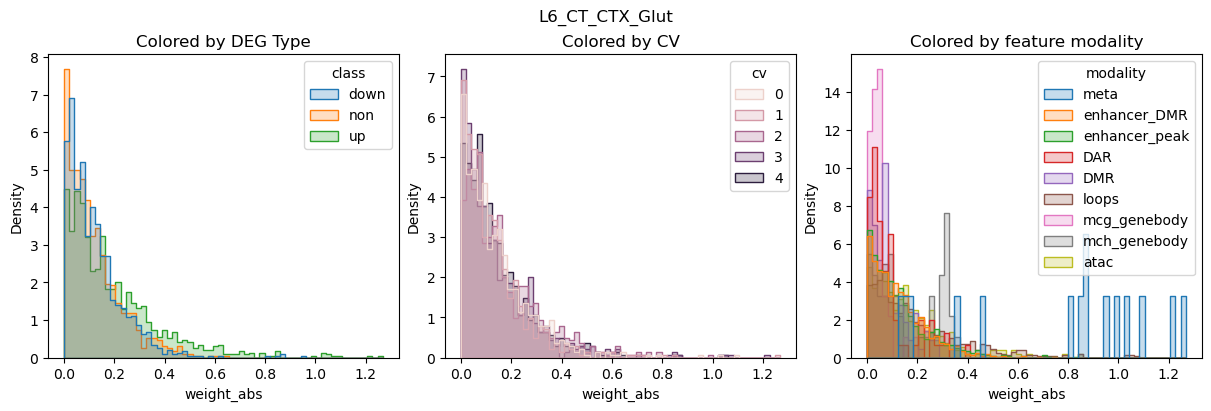

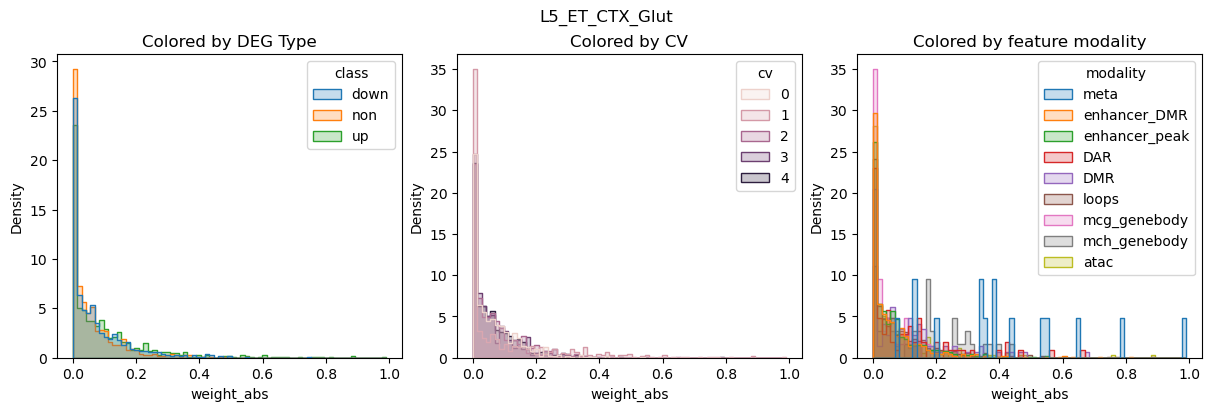

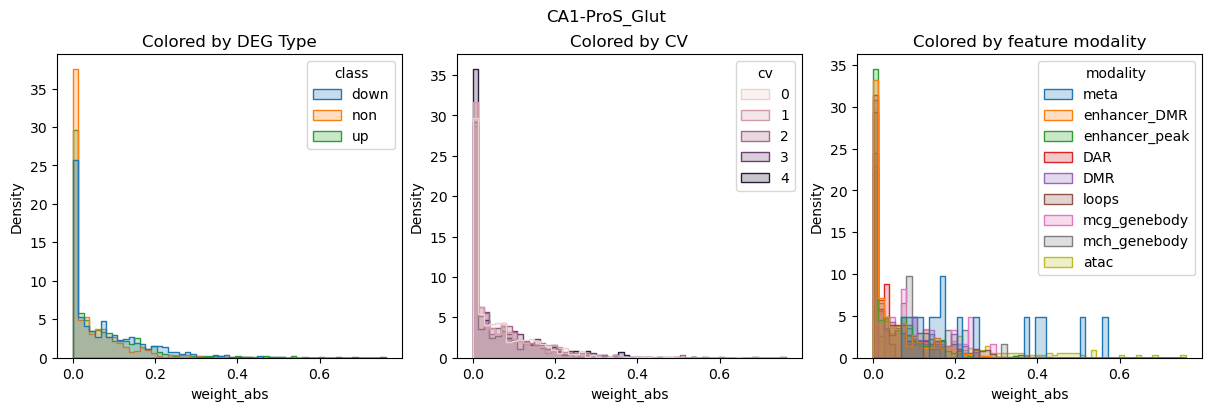

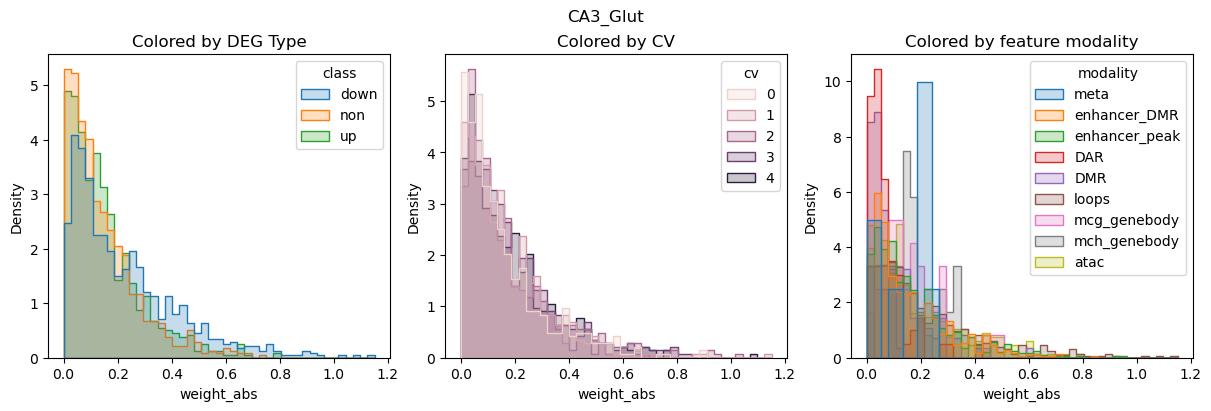

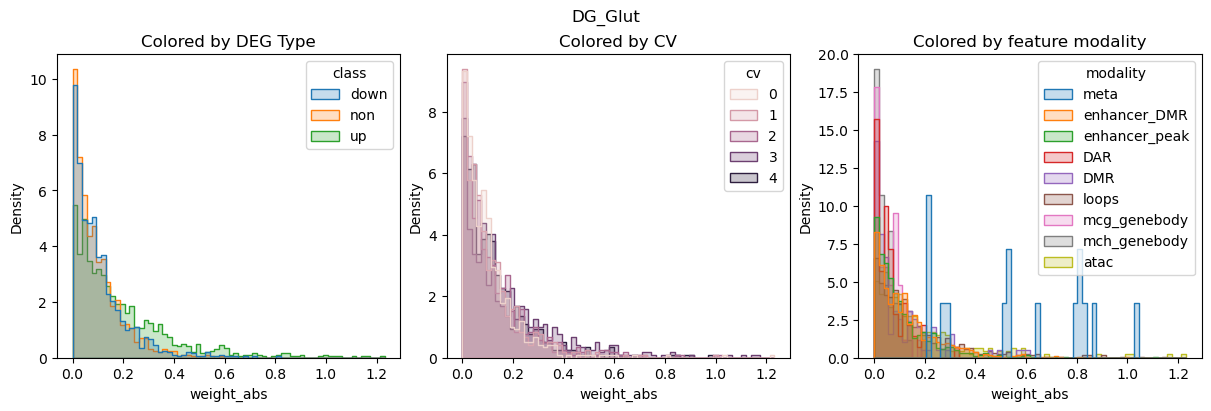

In [9]:
counts_list = []
for i, _ct in enumerate(cell_types): 

    df_weights = pd.read_csv(f"../result_data/linear_baseline/model_weights/{_ct}.weights.csv", index_col=0)
    df_weights['modality'] = [c.split('.')[-1] for c in df_weights.feature]
    df_weights['weight_abs'] = df_weights['weight'].abs()
    # with open(f"../result_data/linear_baseline/model_weights/{_ct}.weights.pkl", "rb") as f: 
    #     weights = pickle.load(f)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    
    ax = axes[0]
    sns.histplot(data=df_weights, x='weight_abs', hue='class', common_norm=False, element='step', stat='density', ax=ax)
    ax.set_title("Colored by DEG Type")
    
    ax = axes[1]
    sns.histplot(data=df_weights, x='weight_abs', hue='cv', common_norm=False, element='step', stat='density', ax=ax)
    ax.set_title("Colored by CV")
    
    ax = axes[2]
    sns.histplot(data=df_weights, x='weight_abs', hue='modality', common_norm=False, element='step', stat='density', ax=ax)
    ax.set_title("Colored by feature modality")
    # ax.legend(loc='upper left', bbox_to_anchor=(0.9, 0, 1.0, 1))

    plt.suptitle(_ct)
    plt.show()

    df_c = pd.DataFrame(df_weights.loc[(df_weights['weight_abs'] > 0.1)].groupby(["modality"])['weight_abs'].count())
    df_c.columns = [_ct]
    
    counts_list.append(df_c)
df_counts = pd.concat(counts_list, axis=1).fillna(0)

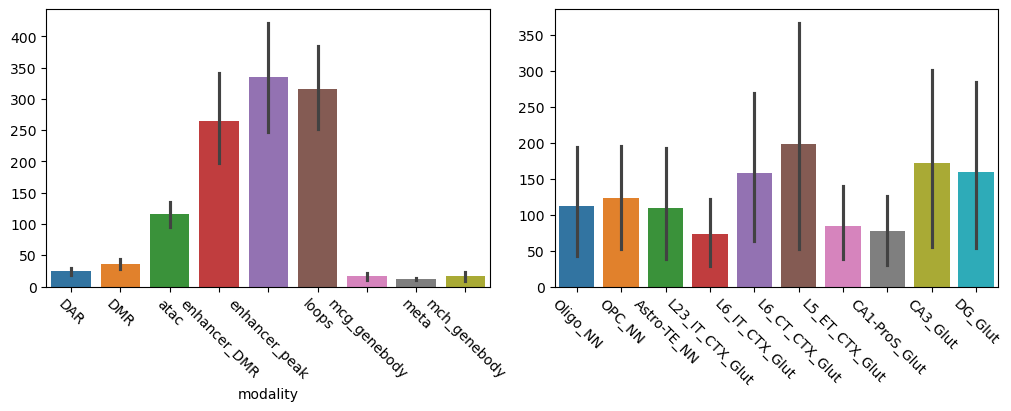

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
sns.barplot(df_counts.T, ax=axes[0])
axes[0].tick_params(axis='x', rotation=-45, left=True)

sns.barplot(df_counts, ax=axes[1])
axes[1].tick_params(axis='x', rotation=-45, left=True)

plt.show()

### Modality Importance

In [12]:
def generate():
    proba = np.random.random()
    max = 0
    for i in range(1,M+1):
         max += (1/3)**i
         if(proba<= max):
              return i-1
    return generate()

In [13]:
palette = {-1: '#4287f5', 0: '#ebedf0', 1: '#f50511'}

FEATURE_LIST = ['DMR', 'mcg_genebody', 'mch_genebody', 'atac', 'DAR', 'loops', 'enhancer_DMR', 'enhancer_peak'] #, 'meta']
FEATURE_MAP = {'DMR' : "mCG_DMR",
               'mcg_genebody' : "mCG_Genebody",
               'mch_genebody' : "mCH_Genebody",
               'atac' : "ATAC",
               'DAR' : "ATAC",
               'loops' : "hic_loops",
               'enhancer_DMR' : "enhancer_DMR",
               'enhancer_peak' : "enhancer_peak"
}
FEAT_ORDER = ["mCG_DMR", "mCG_Genebody", "mCH_Genebody", "ATAC", "hic_loops", "enhancer_DMR", "enhancer_peak"]

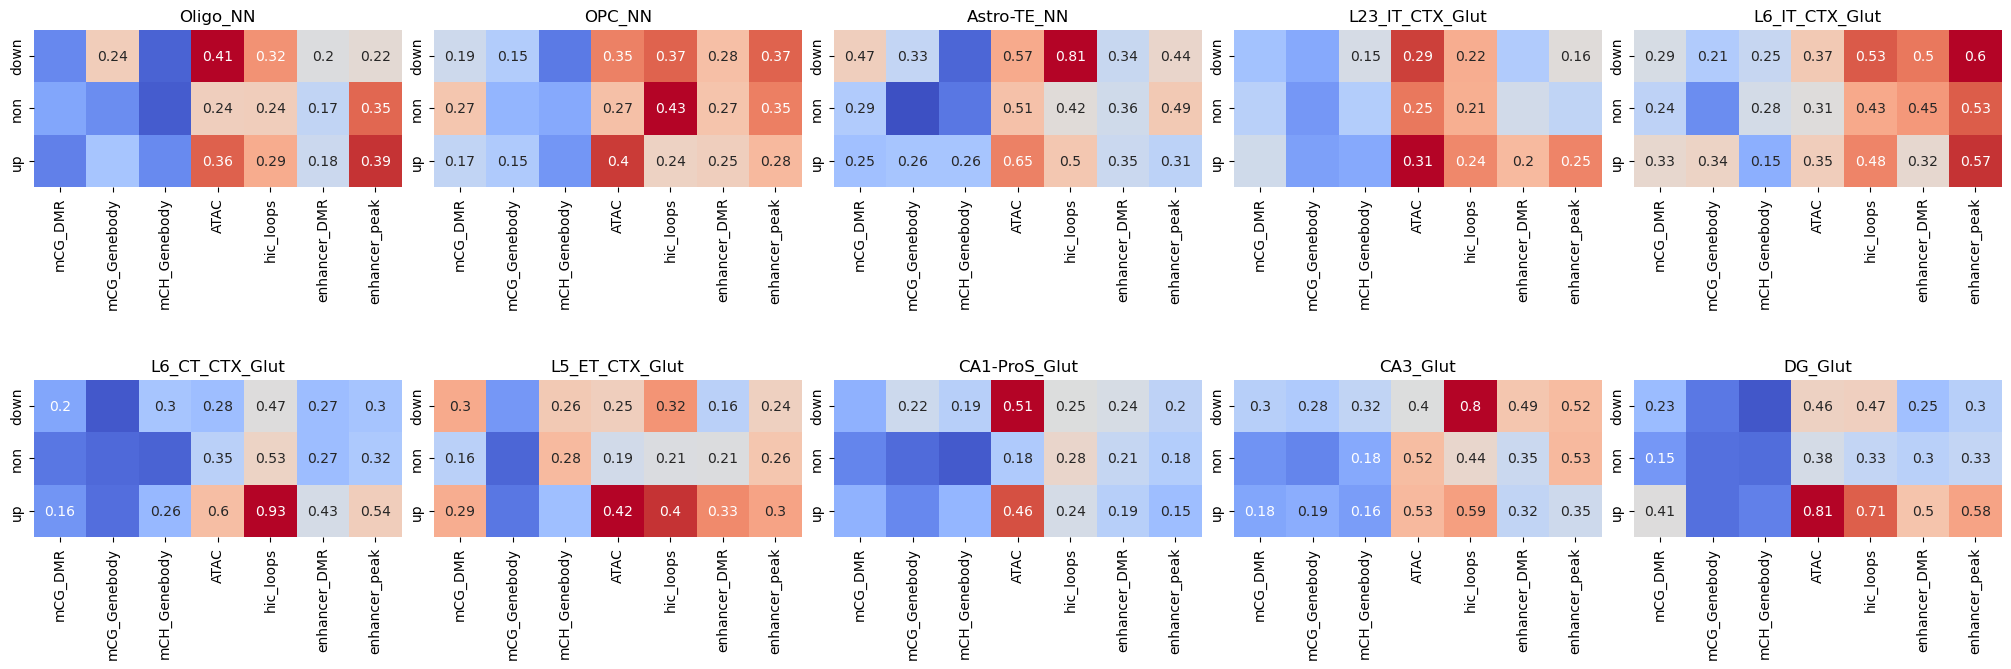

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7), constrained_layout=True)
CT_RES = {}
for i, _ct in enumerate(cell_types): 
    ax = axes.flatten()[i]
    
    df_weights = pd.read_csv(f"../result_data/linear_baseline/model_weights/{_ct}.weights.csv", index_col=0)
    df_weights['modality'] = [c.split('.')[-1] for c in df_weights.feature]
    df_weights['weight_abs'] = df_weights['weight'].abs()
    df_weights['modality'] = df_weights['modality'].map(FEATURE_MAP)

    RES = {}
    df_agg = pd.DataFrame(df_weights.groupby(['modality', 'class', 'feature'])['weight_abs'].mean()).reset_index()
    for _deg, _int_deg in zip(['down', 'non', 'up'], [0, 1, 2]):     
        df_class = df_agg.loc[df_agg['class'] == _deg].copy()
        df_list = []
        for m in FEAT_ORDER: 
            df_temp = df_class[df_class['modality'] == m]
            df_temp = df_temp.drop(columns = ['modality', 'class', 'feature'])
            M = df_temp.shape[0]
        
            res = [0 for i in range(M)]
            for i in range(1000):
                res[generate()]+=1
            
            df_temp = df_temp.apply(lambda x: np.average(sorted(x, reverse=True), weights=res), axis=0)
            df_list.append(pd.DataFrame(df_temp).rename(columns={0:m}).T)
            df_mod = pd.concat(df_list) # .rename(columns={'weight_abs':_deg})
            # df_mods = df_mods.apply(lambda x: (x - min(x)) / sum(x - min(x)), axis=0)
        RES[_deg] = df_mod['weight_abs']
    
    CT_RES[_ct] = RES
    
    sns.heatmap(pd.DataFrame.from_dict(RES).T, square=True, cmap='coolwarm', annot=True, cbar = False, ax=ax, 
                    vmin=0)
    # setting the annotation only when bigger than some value
    for t in ax.texts:
        if float(t.get_text())>=0.15:
            t.set_text(t.get_text()) #if the value is greater than 0.4 then I set the text 
        else:
            t.set_text("") # if not it sets an empty text
    ax.set_title(f"{_ct}")
    
for i in range(len(cell_types), 10): 
    axes.flatten()[i].remove()
plt.show()

In [40]:
# mod_weights = pd.DataFrame(df_weights.loc[(df_weights['weight_abs'] > 0.05)].groupby(['modality', 'class', 'cv'])['weight_abs'].sum().groupby(['modality', 'class']).mean()).reset_index().pivot(index='class', columns='modality')
# mod_weights.columns = mod_weights.columns.droplevel()

# sns.heatmap(mod_weights, square=True, cmap='coolwarm', annot=True, cbar = True)
# plt.show()

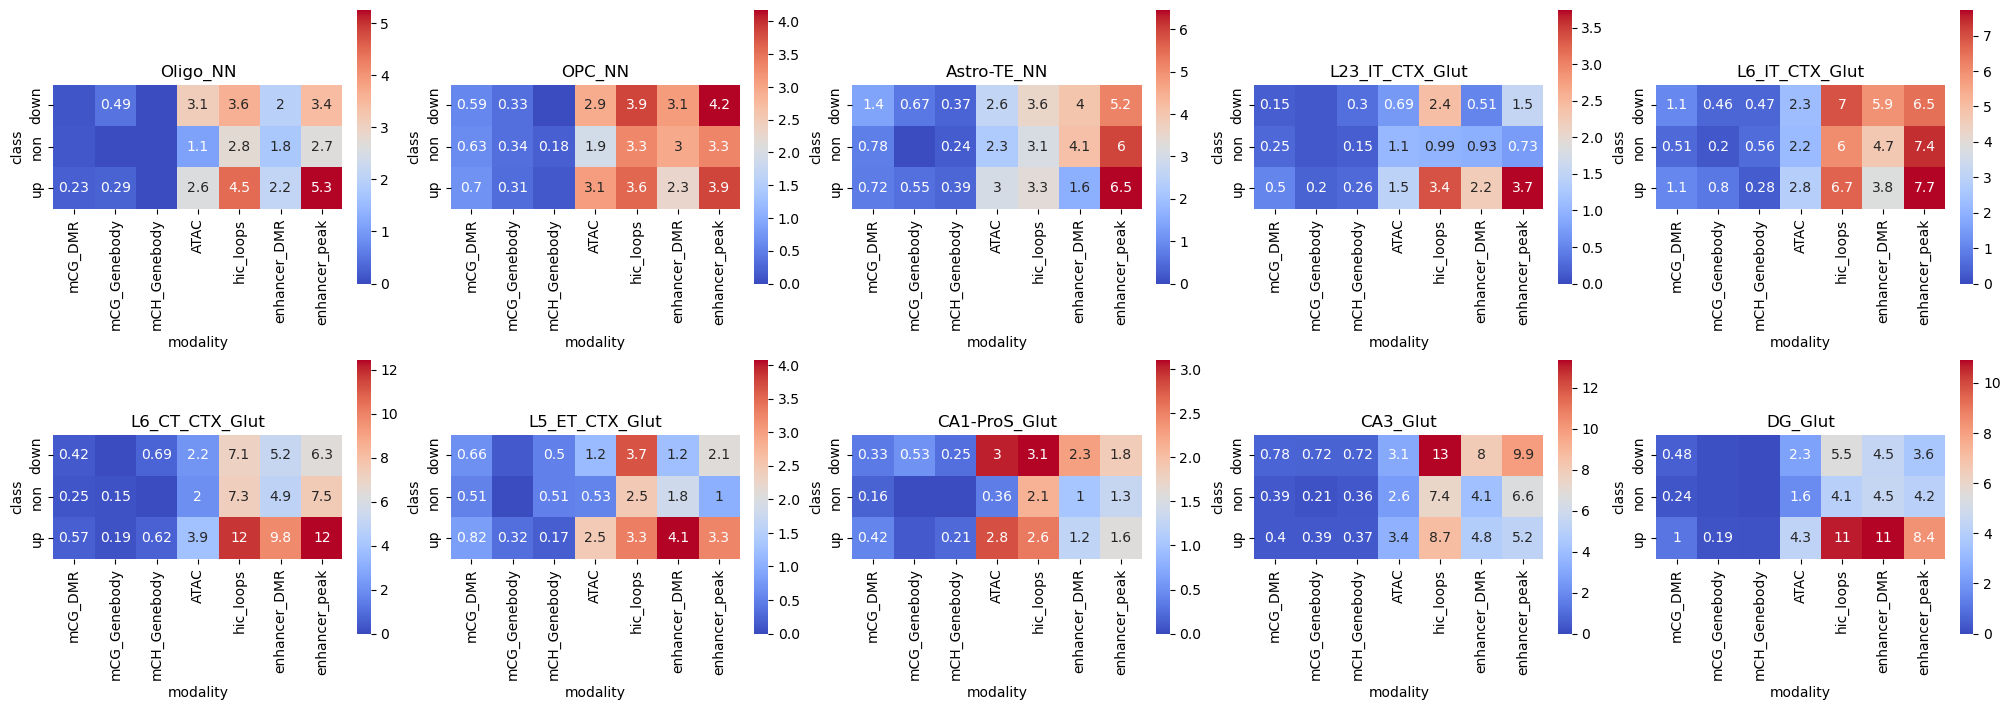

In [39]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7), constrained_layout=True)
CT_RES = {}
for i, _ct in enumerate(cell_types): 
    ax = axes.flatten()[i]
    
    df_weights = pd.read_csv(f"../result_data/linear_baseline/model_weights/{_ct}.weights.csv", index_col=0)
    df_weights['modality'] = [c.split('.')[-1] for c in df_weights.feature]
    df_weights['weight_abs'] = df_weights['weight'].abs()
    df_weights['modality'] = df_weights['modality'].map(FEATURE_MAP)
    
    mod_weights = pd.DataFrame(df_weights.loc[(df_weights['weight_abs'] > 0.1)].groupby(['modality', 'class', 'cv'])['weight_abs'].sum().groupby(['modality', 'class']).mean()).reset_index().pivot(index='class', columns='modality')
    mod_weights.columns = mod_weights.columns.droplevel()
    # Making sure there is all the columns for each cell type 
    to_add = set(FEAT_ORDER).difference(mod_weights.columns)
    for m in to_add:
        mod_weights[m] = 0
    mod_weights = mod_weights[FEAT_ORDER].fillna(0) # reindexing into the same order each time

    # RES = {}
    
    # for m in FEAT_ORDER: 
    CT_RES[_ct] = mod_weights

    sns.heatmap(mod_weights, square=True, cmap='coolwarm', annot=True, cbar = True, ax=ax, vmin=0)
    
    # setting the annotation only when bigger than some value
    for t in ax.texts:
        if float(t.get_text())>=0.15:
            t.set_text(t.get_text()) #if the value is greater than 0.4 then I set the text 
        else:
            t.set_text("") # if not it sets an empty text
    ax.set_title(f"{_ct}")
    
for i in range(len(cell_types), 10): 
    axes.flatten()[i].remove()
plt.show()

### Correlation Plot

In [41]:
df_list = []
for _ct, df_mod in CT_RES.items(): 
    df_mod = df_mod.melt(ignore_index=False).reset_index()
    df_mod['deg_modality'] = df_mod['class'] + '_' + df_mod['modality']
    df_mod = df_mod.drop(columns = ['class', 'modality']).set_index('deg_modality')
    df_mod.columns = [_ct]
    df_list.append(df_mod)
df_mod = pd.concat(df_list, axis=1).fillna(0)

In [463]:
# df_list = []
# for _ct, shap_dict in CT_RES.items(): 
#     df_mod = pd.DataFrame.from_dict(shap_dict).reset_index().melt(id_vars='index', value_name=_ct)
#     df_mod['deg_modality'] = df_mod['variable'] + '_' + df_mod['index']
#     df_mod = df_mod.drop(columns = ['variable', 'index']).set_index('deg_modality')
#     df_list.append(df_mod)
# df_mod = pd.concat(df_list, axis=1)

<Axes: >

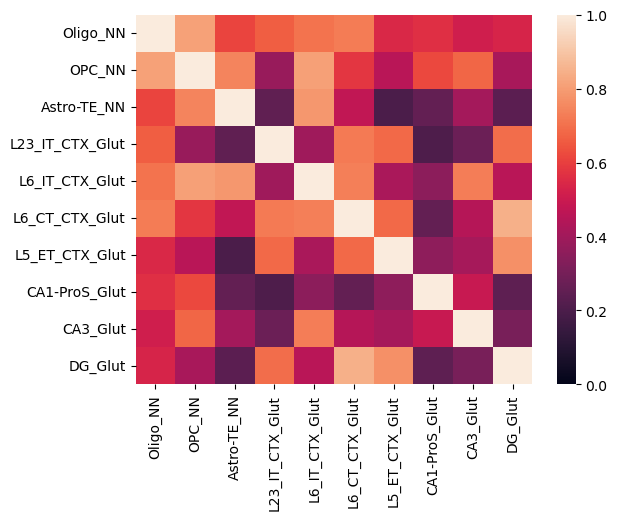

In [42]:
corr_vals = df_mod[cell_types].corr()
corr_vals = np.power(corr_vals, 3)
sns.heatmap(corr_vals, vmin = 0, vmax = 1)

### Clustered Correlation Plot

In [43]:
import scipy.cluster.hierarchy as spc

In [44]:
pdist = spc.distance.pdist(df_mod.T)
linkage = spc.linkage(pdist, method='complete')
idx = spc.fcluster(linkage, 0.5*pdist.max(), 'distance')

In [45]:
columns = [df_mod.columns.tolist()[i] for i in list(np.argsort(idx))]

<Axes: >

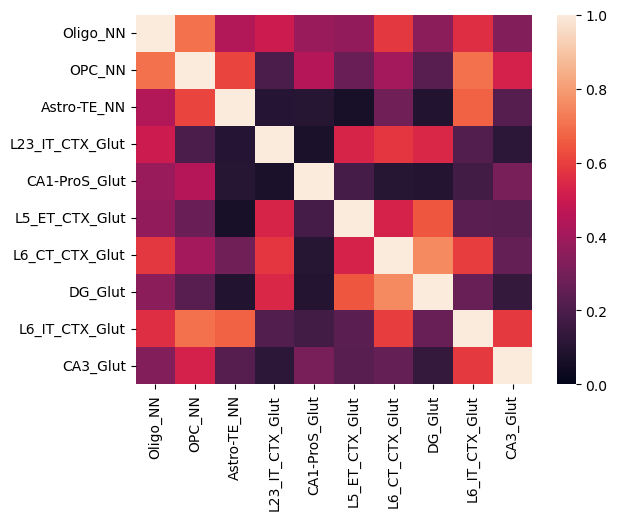

In [46]:
corr_vals = df_mod[columns].corr()
corr_vals = np.power(corr_vals, 5)
sns.heatmap(corr_vals, vmin = 0, vmax = 1)

# OLD

In [192]:
df_weights['modality'] = [c.split('.')[-1] for c in df_weights.feature]
df_weights['weight_abs'] = df_weights['weight'].abs()

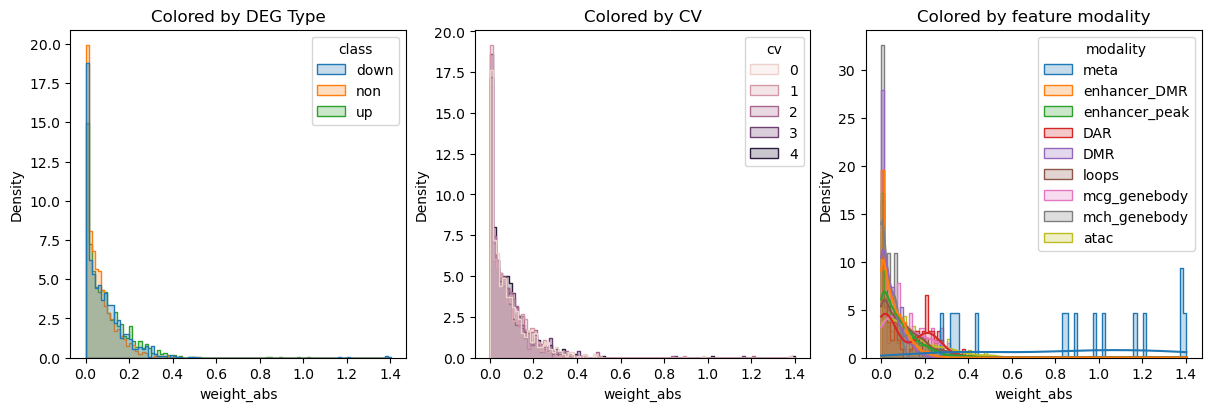

In [264]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
ax = axes[0]
sns.histplot(data=df_weights, x='weight_abs', hue='class', common_norm=False, element='step', stat='density', ax=ax)
ax.set_title("Colored by DEG Type")

ax = axes[1]
sns.histplot(data=df_weights, x='weight_abs', hue='cv', common_norm=False, element='step', stat='density', ax=ax)
ax.set_title("Colored by CV")

ax = axes[2]
sns.histplot(data=df_weights, x='weight_abs', hue='modality', kde=True, common_norm=False, element='step', stat='density', ax=ax)
ax.set_title("Colored by feature modality")
# ax.legend(loc='upper left', bbox_to_anchor=(0.9, 0, 1.0, 1))

plt.show()

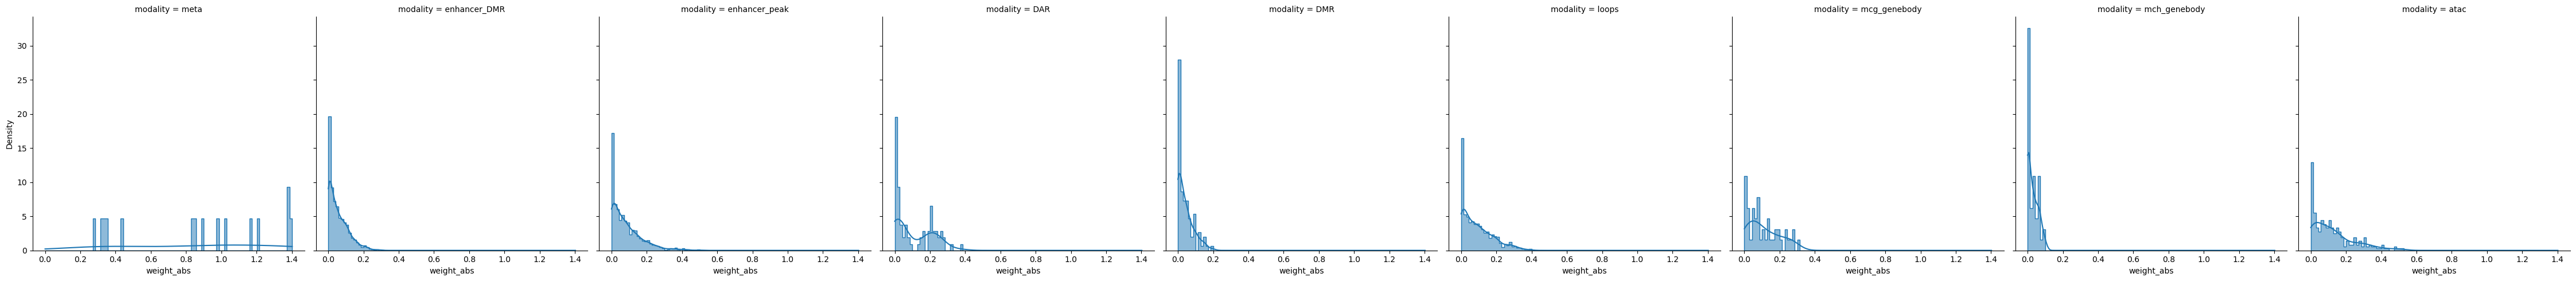

In [263]:
sns.displot(data=df_weights, x='weight_abs', col='modality', kde=True, common_norm=False, element='step', stat='density')
# ax.set_title("Colored by feature modality")

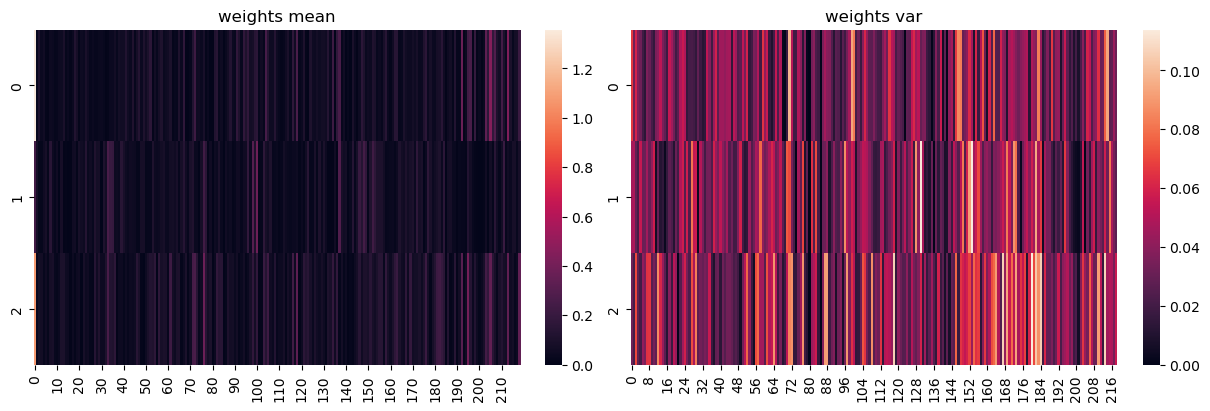

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
sns.heatmap(np.abs(np.asarray(weights)).mean(axis=0), ax=axes[0])
axes[0].set_title("weights mean")
sns.heatmap(np.abs(np.asarray(weights)).std(axis=0), ax=axes[1])
axes[1].set_title("weights var")
plt.show()

In [271]:
pd.DataFrame(df_weights.loc[(df_weights['weight_abs'] > 0.1)].groupby(["modality"])['weight_abs'].count())

,weight_abs
modality,
DAR,31
DMR,11
atac,124
enhancer_DMR,202
enhancer_peak,305
loops,297
mcg_genebody,20
meta,15


In [436]:
mod_weights

modality,ATAC,enhancer_DMR,enhancer_peak,hic_loops,mCG_DMR,mCG_Genebody,mCH_Genebody
class,,,,,,,
down,2.486102,5.506219,4.956385,6.429413,0.602984,0.174864,0.068925
non,2.105750,5.536940,5.216042,4.994329,0.329849,0.125296,0.085813
up,4.618161,11.685918,9.304933,11.300655,1.025144,0.169314,0.190040


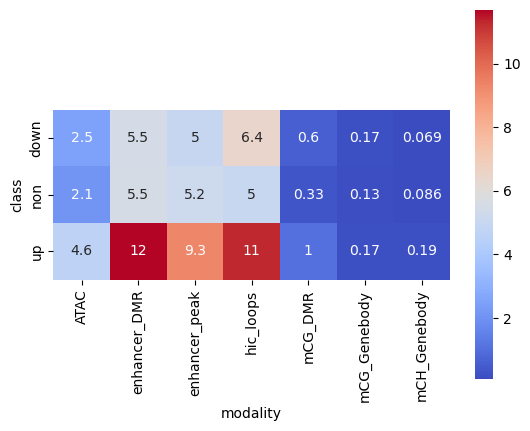

In [435]:
mod_weights = pd.DataFrame(df_weights.loc[(df_weights['weight_abs'] > 0.05)].groupby(['modality', 'class', 'cv'])['weight_abs'].sum().groupby(['modality', 'class']).mean()).reset_index().pivot(index='class', columns='modality')
mod_weights.columns = mod_weights.columns.droplevel()

sns.heatmap(mod_weights, square=True, cmap='coolwarm', annot=True, cbar = True)
plt.show()

In [227]:
mod_weights

weight_abs                                                           \
modality        DAR       DMR      atac enhancer_DMR enhancer_peak     loops   
class                                                                          
down       0.031243  0.023627  0.042715     0.032452      0.030919  0.038342   
non        0.006710  0.042908  0.027800     0.032393      0.036768  0.030228   
up         0.040490  0.019847  0.043878     0.035136      0.036990  0.035135   

                                    
modality mcg_genebody mch_genebody  
class                               
down         0.034958     0.019399  
non          0.043326     0.012374  
up           0.040379     0.051362

In [208]:
(df_weights['weight_abs'] < 0.1).sum() / df_weights.shape[0]

0.6940639269406392